In [10]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# ============================================================
# 1. Load data
# ============================================================
path = "/content/data_drg - Main Data.csv"
df = pd.read_csv(path)
#df = df[df["year"] != 2020]
print(len(df))

# ============================================================
# 2. Function to clean numbers with commas and %
# ============================================================
def clean_numeric(series, percent=False):
    s = (
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.strip()
    )
    s = pd.to_numeric(s, errors="coerce")
    if percent:
        s = s / 100
    return s

print(len(df))

# ============================================================
# 3. Clean columns
# ============================================================
df["inpatient_discharges"] = clean_numeric(df["inpatient_discharges"])
df["avg_inpatient_cost"] = clean_numeric(df["avg_inpatient_cost"])
df["total_expenditure"] = clean_numeric(df["total_expenditure"])
df["gdp_per_capita"] = clean_numeric(df["gdp_per_capita"])
df["aging_rate"] = clean_numeric(df["aging_rate"], percent=True)
df["exposure"] = clean_numeric(df["exposure"], percent=True)
df["physicians_per_1000"] = clean_numeric(df["physicians_per_1000"])
df["beds_per_1000"] = clean_numeric(df["beds_per_1000"])


# ============================================================
# 4. Create post-policy dummy and interaction term
# ============================================================
df["exposure"] = df["exposure"].fillna(0)
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["post"] = (df["year"] >= 2019).astype(int)
df["exposure_post"] = df["exposure"] * df["post"]

# ============================================================
# 5. Construct log variables
# ============================================================
df["ln_avg_cost"] = np.log(df["avg_inpatient_cost"])
df["ln_volume"] = np.log(df["inpatient_discharges"])
df["ln_total_exp"] = np.log(df["total_expenditure"])
df["ln_gdp_pc"] = np.log(df["gdp_per_capita"])

# ============================================================
# 6. Control block X
# ============================================================
X = "ln_gdp_pc + aging_rate + physicians_per_1000 + beds_per_1000"

# ============================================================
# 7. Regression dataset
# ============================================================
reg_df = df[
    [
        "province",
        "year",
        "ln_avg_cost",
        "ln_volume",
        "ln_total_exp",
        "exposure_post",
        "ln_gdp_pc",
        "aging_rate",
        "physicians_per_1000",
        "beds_per_1000",
    ]
].dropna()

print("Regression sample size:", reg_df.shape)

# ============================================================
# 8. Run models (ALL WITH CONTROLS)
# ============================================================
m_cost = smf.ols(
    f"ln_avg_cost ~ exposure_post + {X} + C(province) + C(year)",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["province"]})

m_volume = smf.ols(
    f"ln_volume ~ exposure_post + {X} + C(province) + C(year)",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["province"]})

m_total = smf.ols(
    f"ln_total_exp ~ exposure_post + {X} + C(province) + C(year)",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["province"]})

# ============================================================
# 9. Function to summarize model results
# ============================================================
def summarize_model(model, variable="exposure_post"):
    return {
        "coef": model.params.get(variable, np.nan),
        "std_error": model.bse.get(variable, np.nan),
        "p_value": model.pvalues.get(variable, np.nan),
        "R_squared": model.rsquared,
        "N": int(model.nobs)
    }

# ============================================================
# 10. Summary results table
# ============================================================
results = pd.DataFrame({
    "Avg Cost": summarize_model(m_cost, "exposure_post"),
    "Volume": summarize_model(m_volume, "exposure_post"),
    "Total Expenditure": summarize_model(m_total, "exposure_post")
}).T

results = results.round(4)

print("\nResults summary:")
print(results)

# ============================================================
# 11. Decomposition check
# ln(Total Expenditure) = ln(Volume) + ln(Avg Cost)
# ============================================================
beta_total = results.loc["Total Expenditure", "coef"]
beta_volume = results.loc["Volume", "coef"]
beta_cost = results.loc["Avg Cost", "coef"]

print("\nDecomposition check:")
print("beta_total =", beta_total)
print("beta_volume =", beta_volume)
print("beta_cost =", beta_cost)
print("beta_volume + beta_cost =", round(beta_volume + beta_cost, 4))

217
217
Regression sample size: (217, 10)

Results summary:
                     coef  std_error  p_value  R_squared      N
Avg Cost          -0.0124     0.0152   0.4155     0.9858  217.0
Volume            -0.0104     0.0403   0.7959     0.9959  217.0
Total Expenditure -0.0228     0.0393   0.5613     0.9956  217.0

Decomposition check:
beta_total = -0.0228
beta_volume = -0.0104
beta_cost = -0.0124
beta_volume + beta_cost = -0.0228


In [47]:
df.groupby("year")["exposure"].describe()

,count,mean,std,min,25%,50%,75%,max
year,,,,,,,,
2017,31.0,0.032258,0.179605,0.0,0.00000,0.0000,0.0000,1.00
2018,31.0,0.005484,0.030533,0.0,0.00000,0.0000,0.0000,0.17
2019,31.0,0.232400,0.312303,0.0,0.06515,0.1282,0.1919,1.00
2020,31.0,0.232400,0.312303,0.0,0.06515,0.1282,0.1919,1.00
2021,31.0,0.232400,0.312303,0.0,0.06515,0.1282,0.1919,1.00
2022,31.0,0.477419,0.204466,0.4,0.40000,0.4000,0.4000,1.00
2023,31.0,0.738710,0.102233,0.7,0.70000,0.7000,0.7000,1.00


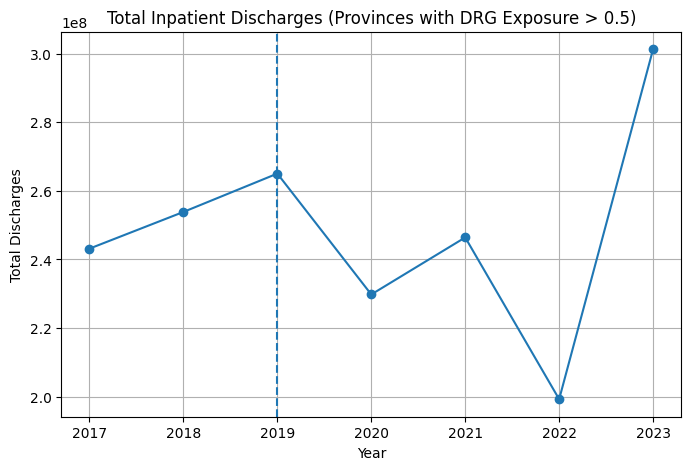

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# load data
df = pd.read_csv("/content/data_drg - Main Data.csv")

# convert exposure to numeric if needed
df["exposure"] = (
    df["exposure"]
    .astype(str)
    .str.replace("%","",regex=False)
)
df["exposure"] = pd.to_numeric(df["exposure"], errors="coerce") / 100

# convert discharges
df["inpatient_discharges"] = (
    df["inpatient_discharges"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df["inpatient_discharges"] = pd.to_numeric(df["inpatient_discharges"], errors="coerce")

# find provinces with exposure > 0.5 after 2019
high_drg_provinces = df[(df["year"] >= 2019) & (df["exposure"] > 0.5)]["province"].unique()

# keep only these provinces
df_high = df[df["province"].isin(high_drg_provinces)]

# sum discharges by year
trend = df_high.groupby("year")["inpatient_discharges"].sum()

# plot
plt.figure(figsize=(8,5))
plt.plot(trend.index, trend.values, marker="o")

plt.axvline(2019, linestyle="--")

plt.title("Total Inpatient Discharges (Provinces with DRG Exposure > 0.5)")
plt.xlabel("Year")
plt.ylabel("Total Discharges")
plt.grid(True)

plt.show()

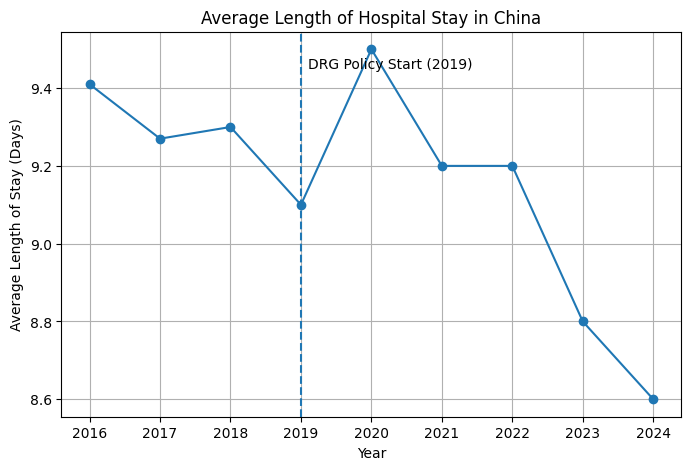

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Create the dataset
data = {
    "year": [2016,2017,2018,2019,2020,2021,2022,2023,2024],
    "avg_length_of_stay": [9.41,9.27,9.30,9.10,9.50,9.20,9.20,8.80,8.60]
}

df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(8,5))
plt.plot(df["year"], df["avg_length_of_stay"], marker="o")

# mark DRG policy start
plt.axvline(x=2019, linestyle="--", linewidth=1.5)
plt.text(2019.1, 9.45, "DRG Policy Start (2019)")

plt.title("Average Length of Hospital Stay in China")
plt.xlabel("Year")
plt.ylabel("Average Length of Stay (Days)")
plt.grid(True)

plt.show()